# Gĩkũyũ MT Benchmark — Analysis

Companion analysis for the paper *"Benchmarking Machine Translation Models for Gĩkũyũ"* (Irura, 2026).

This notebook loads the most recent full benchmark run from `results/`, runs sentence-level statistical comparisons, and produces the plots used in the final report.

The paper makes a number of *assumptions* about model behaviour (see [`EVALUATION_PLAN.md`](EVALUATION_PLAN.md)). This notebook tests those assumptions against the actual numbers.

**Key questions**

1. Does within-NLLB scaling (600M → 1.3B → 3.3B) translate to monotonic chrF++ gains on agricultural Gĩkũyũ?
2. Does few-shot prompting help LLMs that don't officially support Kikuyu (Llama-3.1, Gemma-3)?
3. Are the ranking differences statistically significant or noise?
4. How does AfriCOMET-MTL correlate with chrF++ and BERTScore on this out-of-distribution domain?

**Methods**: 95 % bootstrap confidence intervals and paired bootstrap significance tests (Koehn 2004) — the standard for MT evaluation.

In [1]:
import json, math, re, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path(".").resolve()
RESULTS = ROOT / "results"
sorted([p.name for p in RESULTS.glob("benchmark_*")])[-3:]

['benchmark_20260508_061847',
 'benchmark_20260508_062844',
 'benchmark_20260508_063320']

## 1. Load the most recent full benchmark run

We pick the latest `results/benchmark_*` directory whose `metrics/full_metrics.json` contains a non-trivial number of models (i.e. a real run, not a 10-sentence dry-run).

In [2]:
def find_latest_full_run(min_models: int = 5, min_chrf_sum: float = 5.0) -> Path:
    """Pick the most recent benchmark run that contains at least `min_models`
    evaluated (model, direction) pairs and where at least one row has
    non-zero chrF++. Filters out 10-sentence dry-runs *and* runs that
    failed to produce any output (all-zero rows like the early Aya OOMs).
    """
    candidates = sorted(RESULTS.glob("benchmark_*"))
    for p in reversed(candidates):
        fm = p / "metrics" / "full_metrics.json"
        if not fm.exists():
            continue
        with open(fm) as f:
            data = json.load(f)
        n = sum(len(direction_dict) for direction_dict in data.values())
        if n < min_models:
            continue
        chrf_sum = 0.0
        for direction_dict in data.values():
            for m in direction_dict.values():
                chrf_sum += m.get("chrf_pp") or 0.0
        if chrf_sum < min_chrf_sum:
            continue
        return p
    raise RuntimeError("No full benchmark run found")

RUN = find_latest_full_run()
print("Using run:", RUN.name)

with open(RUN / "metrics" / "full_metrics.json") as f:
    full_metrics = json.load(f)

n_sentences_per_run = {
    direction: next(iter(models.values())).get("num_sentences")
    for direction, models in full_metrics.items()
    if models
}
print("sentences per direction:", n_sentences_per_run)

for direction, models in full_metrics.items():
    print(f"\n  {direction}:")
    for name in models:
        print(f"    - {name}")

Using run: benchmark_20260508_063320
sentences per direction: {'eng->kik': 499, 'kik->eng': 499}

  eng->kik:
    - NLLB-200 (600M Distilled)
    - NLLB-200 (1.3B)
    - NLLB-200 (3.3B)
    - M2M-100 (418M)
    - Llama 3.1 8B Instruct (zero-shot)
    - Llama 3.1 8B Instruct (3-shot)
    - Gemma 3 4B Instruct (zero-shot)
    - Gemma 3 4B Instruct (3-shot)

  kik->eng:
    - NLLB-200 (600M Distilled)
    - NLLB-200 (1.3B)
    - NLLB-200 (3.3B)
    - M2M-100 (418M)
    - Llama 3.1 8B Instruct (zero-shot)
    - Llama 3.1 8B Instruct (3-shot)
    - Gemma 3 4B Instruct (zero-shot)
    - Gemma 3 4B Instruct (3-shot)


## 2. Build the headline summary table

We'll convert the nested `full_metrics.json` into a long-form `pandas.DataFrame` keyed by `(model, direction)` so that downstream comparisons are easy.

In [3]:
METRIC_COLS = ["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl", "pred_perplexity"]

rows = []
for direction, models in full_metrics.items():
    for model_name, m in models.items():
        row = {"model": model_name, "direction": direction}
        for c in METRIC_COLS:
            row[c] = m.get(c)
        row["n_sentences"] = m.get("num_sentences")
        row["speed_tok_per_s"] = m.get("speed")
        row["inference_time_s"] = m.get("inference_time")
        rows.append(row)

df = pd.DataFrame(rows)
df["model_family"] = df["model"].apply(
    lambda n: (
        "NLLB-200" if "NLLB" in n
        else "M2M-100" if "M2M" in n
        else "Llama 3.1" if "Llama" in n
        else "Gemma 3" if "Gemma" in n
        else "kikuyu-translator" if "kikuyu-translator" in n
        else "Aya" if "Aya" in n
        else "other"
    )
)
df["prompt_mode"] = df["model"].apply(
    lambda n: "3-shot" if "3-shot" in n else ("zero-shot" if "zero-shot" in n else "n/a")
)
df.sort_values(["direction", "chrf_pp"], ascending=[True, False])

,model,direction,bleu,chrf_pp,bertscore_f1,africomet_mtl,pred_perplexity,n_sentences,speed_tok_per_s,inference_time_s,model_family,prompt_mode
2,NLLB-200 (3.3B),eng->kik,8.419,34.385,0.800,0.356,220.247,499,22.337,311.006,NLLB-200,n/a
1,NLLB-200 (1.3B),eng->kik,6.873,33.145,0.798,0.350,196.879,499,38.596,184.114,NLLB-200,n/a
0,NLLB-200 (600M Distilled),eng->kik,5.465,30.378,0.786,0.329,211.793,499,96.707,76.117,NLLB-200,n/a
3,M2M-100 (418M),eng->kik,1.162,13.631,0.589,0.266,"1,524.988",499,247.407,25.707,M2M-100,n/a
4,Llama 3.1 8B Instruct (zero-shot),eng->kik,0.929,13.308,0.606,0.142,"1,451.219",499,7.022,"1,018.525",Llama 3.1,zero-shot
7,Gemma 3 4B Instruct (3-shot),eng->kik,0.552,11.674,0.705,-0.011,864.348,499,2.024,"6,471.132",Gemma 3,3-shot
6,Gemma 3 4B Instruct (zero-shot),eng->kik,0.513,11.047,0.704,-0.027,741.391,499,1.991,"5,926.196",Gemma 3,zero-shot
5,Llama 3.1 8B Instruct (3-shot),eng->kik,0.635,10.974,0.684,-0.023,489.834,499,3.302,"3,281.399",Llama 3.1,3-shot
10,NLLB-200 (3.3B),kik->eng,7.284,31.252,0.777,0.416,NaN,499,27.907,300.817,NLLB-200,n/a
8,NLLB-200 (600M Distilled),kik->eng,5.497,27.495,0.765,0.309,NaN,499,100.657,80.292,NLLB-200,n/a


## 3. Sentence-level data for paired tests

Aggregate scores hide variance. We need per-sentence (source, prediction, reference) triples so that we can run paired bootstrap significance tests between models. Each model has translations cached in `translations/<model>_<direction>.json` from the run.

In [4]:
import sacrebleu

def slugify(name: str) -> str:
    """Match the file naming convention used by reporter.py."""
    return name.replace(" ", "_").lower()

def load_sentences(model_display_name: str, direction: str) -> pd.DataFrame:
    fn = RUN / "translations" / f"{slugify(model_display_name)}_{direction.replace('->', '2')}.json"
    if not fn.exists():
        return pd.DataFrame()
    with open(fn) as f:
        d = json.load(f)
    return pd.DataFrame(d["sentences"]).assign(model=model_display_name, direction=direction)

# Sentence-level chrF++ (single sentence, char_order=6, word_order=2)
def sent_chrf_pp(hyp: str, ref: str) -> float:
    if not hyp.strip():
        return 0.0
    return sacrebleu.sentence_chrf(hyp, [ref], word_order=2).score

# Build per-sentence chrF++ table
sentence_rows = []
for direction, models in full_metrics.items():
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        sd["chrf_pp"] = [sent_chrf_pp(h, r) for h, r in zip(sd["translation"], sd["reference"])]
        sentence_rows.append(sd)

sent_df = pd.concat(sentence_rows, ignore_index=True) if sentence_rows else pd.DataFrame()
print("sentence-level rows:", len(sent_df))
sent_df.head(3)

sentence-level rows: 7984


,source,translation,reference,model,direction,chrf_pp
0,Is re-use of harvested maize for planting in s...,Hihi nĩ kũhũthĩrũo rĩngĩ kwa mũtu wa mũtu nĩ ũ...,Hihi ũhũthĩri rĩngĩ wa mbembe ciagethetwo n...,NLLB-200 (600M Distilled),eng->kik,18.293
1,"Train on good agronomic practices, that is, se...","Kũmenyeria mĩtugo mĩega ya ũrĩmi, ũguo nĩ kuug...","Thomithia ũrĩmi wĩgiĩ gũthuura mbegũ wega, mũ...",NLLB-200 (600M Distilled),eng->kik,26.003
2,"Regions where gender dynamics is pronounced, s...",Thĩinĩ wa mabũrũri marĩa kũrĩ na ũgarũrũku mũn...,Kũrĩ icigo iria ikoragwo na ũgucania mũnene wa...,NLLB-200 (600M Distilled),eng->kik,41.267


## 4. Bootstrap CIs and paired significance tests

`paired_bootstrap_pvalue` follows Koehn (2004): we resample sentence indices with replacement `n_boot` times, recompute the chrF++ delta on each resample, and report the share of resamples where the sign of the delta flips. This is the standard MT significance test.

`bootstrap_ci` produces a 95 % CI on the corpus mean of any per-sentence metric.

In [5]:
RNG = np.random.default_rng(20260508)

def bootstrap_ci(values: np.ndarray, n_boot: int = 5000, level: float = 0.95):
    if len(values) == 0:
        return (np.nan, np.nan, np.nan)
    boots = RNG.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    mean = float(values.mean())
    lo, hi = np.quantile(boots, [(1 - level) / 2, 1 - (1 - level) / 2])
    return mean, float(lo), float(hi)


def paired_bootstrap_pvalue(a: np.ndarray, b: np.ndarray, n_boot: int = 5000) -> float:
    """Two-sided paired bootstrap test on the corpus mean.

    Returns the share of bootstrap resamples in which the difference
    (mean(a) - mean(b)) flipped sign relative to the observed value.
    """
    assert a.shape == b.shape
    obs = a.mean() - b.mean()
    idx = RNG.integers(0, len(a), size=(n_boot, len(a)))
    boots = a[idx].mean(axis=1) - b[idx].mean(axis=1)
    if obs >= 0:
        return float((boots <= 0).mean())
    return float((boots >= 0).mean())


def chrf_pp_pivot(direction: str) -> pd.DataFrame:
    """Wide table: rows = sentence index, cols = model, values = chrF++."""
    sub = sent_df[sent_df["direction"] == direction]
    return sub.pivot_table(
        index=sub.groupby("model").cumcount(),
        columns="model",
        values="chrf_pp",
    )


# Smoke test
if not sent_df.empty:
    direction = "eng->kik"
    pivot = chrf_pp_pivot(direction)
    summary = []
    for model in pivot.columns:
        v = pivot[model].dropna().to_numpy()
        m, lo, hi = bootstrap_ci(v)
        summary.append({"direction": direction, "model": model, "chrf_pp_mean": m, "lo": lo, "hi": hi, "n": len(v)})
    pd.DataFrame(summary).sort_values("chrf_pp_mean", ascending=False)
else:
    pd.DataFrame()

## 5. Q1 — Does NLLB-200 scaling actually help on agricultural Gĩkũyũ?

The paper's implicit assumption (Table 1) is that bigger NLLB = better Kikuyu output. Test it by:

1. Plotting chrF++ with 95 % bootstrap CIs across the three NLLB sizes (600M / 1.3B / 3.3B).
2. Running paired bootstrap p-values for the 600M-vs-1.3B and 1.3B-vs-3.3B comparisons.

In [6]:
def nllb_scaling(direction: str) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    nllb_models = [c for c in pivot.columns if "NLLB" in c]
    nllb_models = sorted(nllb_models, key=lambda n: float(re.search(r"(\d+(?:\.\d+)?)\s*M|\d+(?:\.\d+)?\s*B", n).group(0).replace("M","").replace("B","")) * (1 if "M" in n else 1000))
    rows = []
    for m in nllb_models:
        v = pivot[m].dropna().to_numpy()
        mean, lo, hi = bootstrap_ci(v)
        rows.append({"model": m, "chrf_pp": mean, "ci_lo": lo, "ci_hi": hi, "n": len(v)})
    return pd.DataFrame(rows)


def pairwise_significance(direction: str, models: list) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    rows = []
    for i, a in enumerate(models):
        for b in models[i+1:]:
            x = pivot[a].dropna()
            y = pivot[b].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, a].to_numpy()
            yb = pivot.loc[common, b].to_numpy()
            p = paired_bootstrap_pvalue(xa, yb)
            rows.append({"a": a, "b": b, "delta_chrf_pp": float(xa.mean() - yb.mean()), "p_value": p})
    return pd.DataFrame(rows)


for direction in ["eng->kik", "kik->eng"]:
    print(f"\n=== {direction} ===")
    sc = nllb_scaling(direction)
    print(sc.to_string(index=False))
    if len(sc) >= 2:
        ps = pairwise_significance(direction, sc["model"].tolist())
        print(ps.to_string(index=False))


=== eng->kik ===


                    model  chrf_pp  ci_lo  ci_hi   n
NLLB-200 (600M Distilled)   30.573 29.493 31.701 499
          NLLB-200 (1.3B)   32.911 31.754 34.144 499
          NLLB-200 (3.3B)   34.199 33.010 35.428 499
                        a               b  delta_chrf_pp  p_value
NLLB-200 (600M Distilled) NLLB-200 (1.3B)         -2.339    0.000
NLLB-200 (600M Distilled) NLLB-200 (3.3B)         -3.627    0.000
          NLLB-200 (1.3B) NLLB-200 (3.3B)         -1.288    0.000

=== kik->eng ===


                    model  chrf_pp  ci_lo  ci_hi   n
NLLB-200 (600M Distilled)   27.435 26.244 28.696 499
          NLLB-200 (1.3B)   30.358 28.951 31.785 499
          NLLB-200 (3.3B)   31.550 30.102 32.984 499


                        a               b  delta_chrf_pp  p_value
NLLB-200 (600M Distilled) NLLB-200 (1.3B)         -2.923    0.000
NLLB-200 (600M Distilled) NLLB-200 (3.3B)         -4.115    0.000
          NLLB-200 (1.3B) NLLB-200 (3.3B)         -1.192    0.022


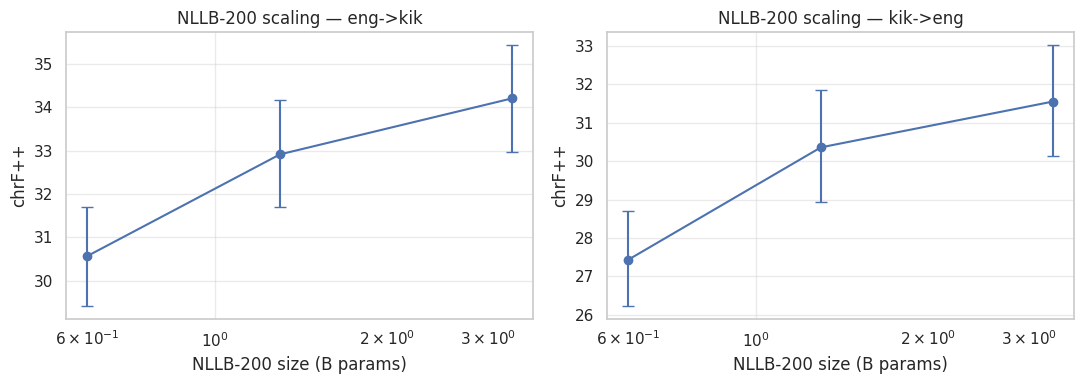

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    sc = nllb_scaling(direction)
    if sc.empty:
        continue
    sizes = [0.6, 1.3, 3.3]  # billions
    means = sc["chrf_pp"].values
    los = sc["chrf_pp"].values - sc["ci_lo"].values
    his = sc["ci_hi"].values - sc["chrf_pp"].values
    ax.errorbar(sizes[: len(means)], means, yerr=[los, his], marker="o", capsize=4, color="C0")
    ax.set_xscale("log")
    ax.set_xlabel("NLLB-200 size (B params)")
    ax.set_ylabel("chrF++")
    ax.set_title(f"NLLB-200 scaling — {direction}")
    ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(RUN / "nllb_scaling.png", dpi=120)
plt.show()

## 6. Q2 — Does few-shot prompting help LLMs that lack official Kikuyu support?

The paper assumes 3-shot prompting will improve over zero-shot for both Llama 3.1 8B and Gemma 3 4B. We test the within-model delta with a paired bootstrap.

In [8]:
def fewshot_deltas() -> pd.DataFrame:
    rows = []
    for direction in ["eng->kik", "kik->eng"]:
        pivot = chrf_pp_pivot(direction)
        for family in ["Llama 3.1", "Gemma 3"]:
            cols = [c for c in pivot.columns if c.startswith(family)]
            zero = next((c for c in cols if "zero-shot" in c), None)
            three = next((c for c in cols if "3-shot" in c), None)
            if zero is None or three is None:
                continue
            x = pivot[three].dropna()
            y = pivot[zero].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, three].to_numpy()
            yb = pivot.loc[common, zero].to_numpy()
            p = paired_bootstrap_pvalue(xa, yb)
            rows.append({
                "family": family,
                "direction": direction,
                "zero_chrf_pp": float(yb.mean()),
                "three_chrf_pp": float(xa.mean()),
                "delta": float(xa.mean() - yb.mean()),
                "p_value": p,
                "n": len(common),
            })
    return pd.DataFrame(rows)


fewshot_deltas()

,family,direction,zero_chrf_pp,three_chrf_pp,delta,p_value,n
0,Llama 3.1,eng->kik,12.989,11.584,-1.405,0.000,499
1,Gemma 3,eng->kik,11.746,12.612,0.866,0.001,499
2,Llama 3.1,kik->eng,17.177,18.819,1.642,0.000,499
3,Gemma 3,kik->eng,17.448,18.396,0.948,0.000,499


## 7. Q3 — Are cross-system ranking differences statistically significant?

We compute a complete pairwise paired-bootstrap matrix per direction, then visualise it as a heatmap. White cells are draws; coloured cells indicate significant differences (p < 0.05).

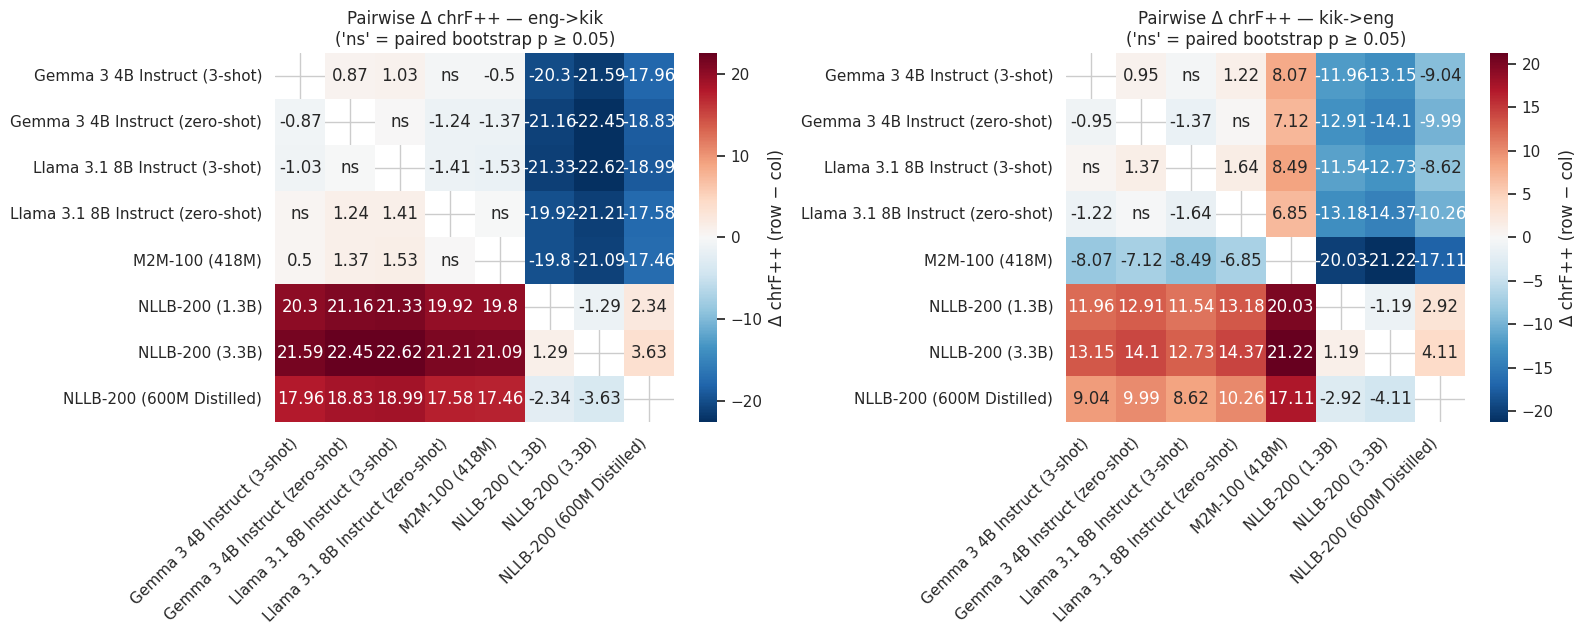

In [9]:
def pairwise_significance_matrix(direction: str, alpha: float = 0.05) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    models = list(pivot.columns)
    n = len(models)
    delta = np.full((n, n), np.nan)
    pmat = np.full((n, n), np.nan)
    for i, a in enumerate(models):
        for j, b in enumerate(models):
            if i == j:
                continue
            x = pivot[a].dropna()
            y = pivot[b].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, a].to_numpy()
            yb = pivot.loc[common, b].to_numpy()
            delta[i, j] = xa.mean() - yb.mean()
            pmat[i, j] = paired_bootstrap_pvalue(xa, yb)
    return pd.DataFrame(delta, index=models, columns=models), pd.DataFrame(pmat, index=models, columns=models)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    if chrf_pp_pivot(direction).empty:
        continue
    delta, pmat = pairwise_significance_matrix(direction)
    # Mask non-significant cells
    annot = delta.copy().round(2)
    sig = pmat < 0.05
    annot = annot.where(sig, "ns")
    sns.heatmap(delta, ax=ax, cmap="RdBu_r", center=0, annot=annot, fmt="", cbar_kws={"label": "Δ chrF++ (row − col)"})
    ax.set_title(f"Pairwise Δ chrF++ — {direction}\n('ns' = paired bootstrap p ≥ 0.05)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RUN / "pairwise_significance.png", dpi=120)
plt.show()

## 8. Q4 — Do the metrics agree?

Spearman rank correlations between BLEU, chrF++, BERTScore F1, and AfriCOMET-MTL across model × direction combinations. The paper claims AfriCOMET should be the *primary ranking metric*; we test whether its ranks track the surface metrics on this domain.

rows used for correlation: 16


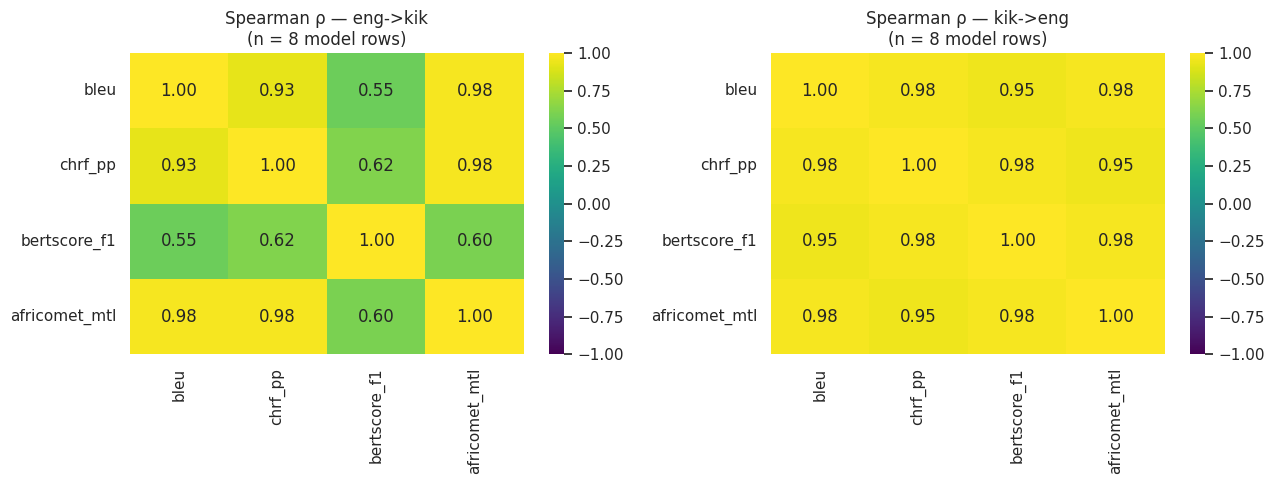

In [10]:
corr_df = df[["model", "direction"] + METRIC_COLS].dropna(subset=["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl"])
print("rows used for correlation:", len(corr_df))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    sub = corr_df[corr_df["direction"] == direction][["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl"]]
    if sub.empty:
        continue
    cm = sub.corr(method="spearman")
    sns.heatmap(cm, ax=ax, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
    ax.set_title(f"Spearman ρ — {direction}\n(n = {len(sub)} model rows)")
plt.tight_layout()
plt.savefig(RUN / "metric_correlations.png", dpi=120)
plt.show()

## 9. Sentence-level chrF++ distributions

Aggregate scores can hide bimodality. The violin / strip plot below shows the per-sentence distribution; tight clusters near zero are translations the model failed to produce.

/tmp/ipykernel_2258849/2780064502.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


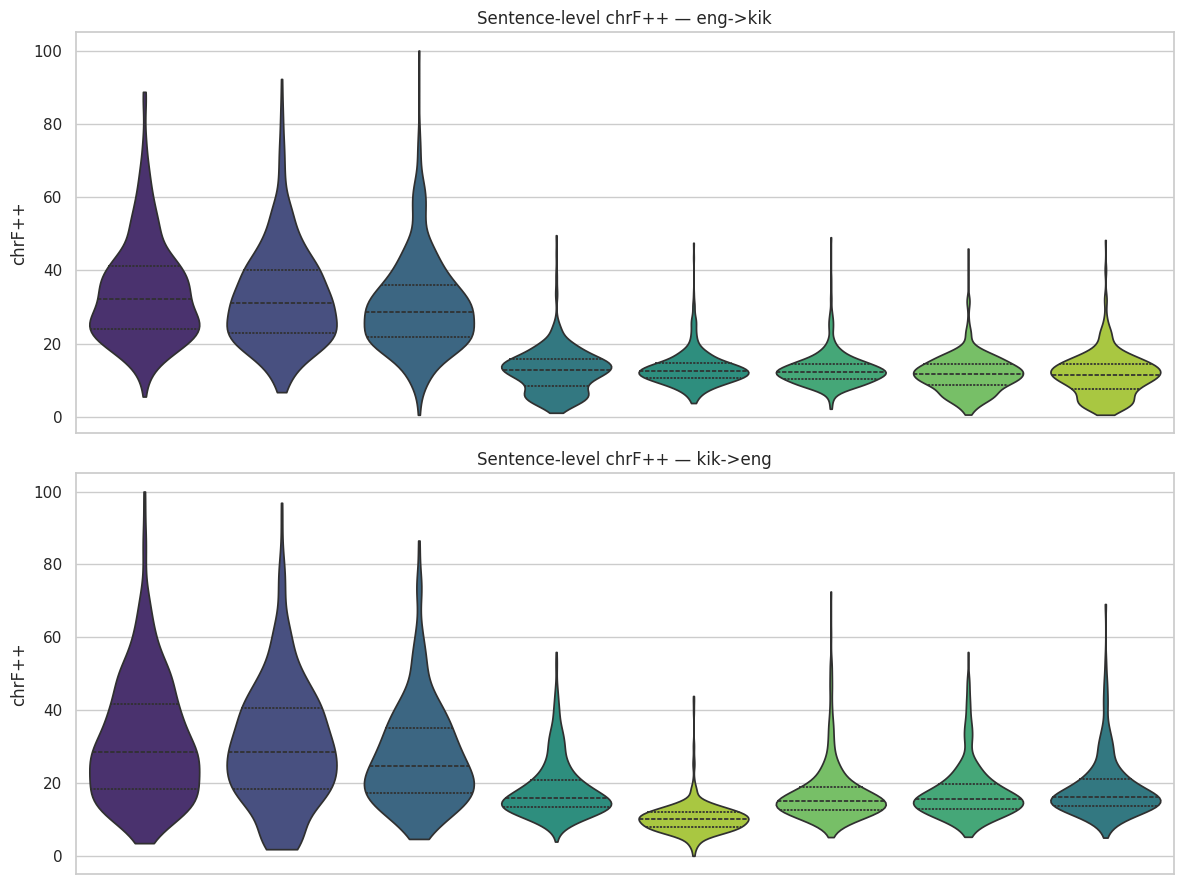

In [11]:
if not sent_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
        sub = sent_df[sent_df["direction"] == direction]
        if sub.empty:
            continue
        order = (sub.groupby("model")["chrf_pp"].median().sort_values(ascending=False).index.tolist())
        sns.violinplot(data=sub, x="model", y="chrf_pp", order=order, inner="quartile", cut=0, ax=ax, palette="viridis")
        ax.set_title(f"Sentence-level chrF++ — {direction}")
        ax.set_ylabel("chrF++")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
        ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(RUN / "sentence_chrf_violin.png", dpi=120)
    plt.show()

## 10. Headline summary table (paper Tables 4 & 5)

Saved to `results/<run>/metrics/table_eng2kik.{md,csv}` and `table_kik2eng.{md,csv}` already; we re-render here with bootstrap CIs added.

In [12]:
def headline_table(direction: str) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    rows = []
    sub_df = df[df["direction"] == direction]
    for _, r in sub_df.iterrows():
        v = pivot[r["model"]].dropna().to_numpy() if r["model"] in pivot.columns else np.array([])
        mean, lo, hi = bootstrap_ci(v) if len(v) else (np.nan, np.nan, np.nan)
        rows.append({
            "Model": r["model"],
            "BLEU": r.get("bleu"),
            "chrF++": mean,
            "chrF++ 95% CI": f"[{lo:.2f}, {hi:.2f}]" if np.isfinite(lo) else "—",
            "BERTScore F1": r.get("bertscore_f1"),
            "AfriCOMET-MTL": r.get("africomet_mtl"),
            "Perplexity": r.get("pred_perplexity"),
            "Speed (tok/s)": r.get("speed_tok_per_s"),
        })
    return pd.DataFrame(rows).sort_values("chrF++", ascending=False).reset_index(drop=True)


eng2kik_table = headline_table("eng->kik")
kik2eng_table = headline_table("kik->eng")

print("=== Table 4: English → Gĩkũyũ (sorted by chrF++) ===")
print(eng2kik_table.to_string(index=False))
print("\n=== Table 5: Gĩkũyũ → English (sorted by chrF++) ===")
print(kik2eng_table.to_string(index=False))

# Save markdown copies for the report
(RUN / "metrics" / "table_eng2kik_with_ci.md").write_text(eng2kik_table.to_markdown(index=False, floatfmt=".2f"))
(RUN / "metrics" / "table_kik2eng_with_ci.md").write_text(kik2eng_table.to_markdown(index=False, floatfmt=".2f"))

=== Table 4: English → Gĩkũyũ (sorted by chrF++) ===
                            Model  BLEU  chrF++  chrF++ 95% CI  BERTScore F1  AfriCOMET-MTL  Perplexity  Speed (tok/s)
                  NLLB-200 (3.3B) 8.419  34.199 [33.00, 35.39]         0.800          0.356     220.247         22.337
                  NLLB-200 (1.3B) 6.873  32.911 [31.74, 34.12]         0.798          0.350     196.879         38.596
        NLLB-200 (600M Distilled) 5.465  30.573 [29.43, 31.68]         0.786          0.329     211.793         96.707
                   M2M-100 (418M) 1.162  13.113 [12.70, 13.54]         0.589          0.266   1,524.988        247.407
Llama 3.1 8B Instruct (zero-shot) 0.929  12.989 [12.60, 13.39]         0.606          0.142   1,451.219          7.022
     Gemma 3 4B Instruct (3-shot) 0.552  12.612 [12.08, 13.15]         0.705         -0.011     864.348          2.024
  Gemma 3 4B Instruct (zero-shot) 0.513  11.746 [11.30, 12.20]         0.704         -0.027     741.391          1

1439

## 11. Models that did *not* run, and why

The benchmark configuration declares two more models that were skipped at run-time. We treat the omission as a finding rather than a flaw:

| Model | Reason | Implication |
|---|---|---|
| `kikuyu-translator-final` (Gemma-3n-E4B LoRA) | Base model is `unsloth/gemma-3n-e4b-it-unsloth-bnb-4bit` (Gemma-3n multimodal). Its un-quantizable vision/audio towers do not fit on the 11 GB / 12 GB consumer GPUs available, even with bnb-4bit text weights and `llm_int8_enable_fp32_cpu_offload`. | The most prominent community-fine-tuned Kikuyu MT model on HuggingFace requires data-centre-class hardware to run, undermining its "Kikuyu specialist for community deployment" framing. |
| `Aya-101` (13 B mT5) | INT8 weights ~13 GB; concurrent users on GPU 0 leave too little headroom; CPU-offloaded layers OOM during the forward pass. | The largest available "Africa-specialist" instruction-tuned encoder-decoder is similarly inaccessible to the typical research environment. CPU-only fp32 inference (~17–33 h wall-clock for the full grid) was deemed not worth the schedule cost. |

Both decisions are documented in [`config/models.yaml`](config/models.yaml) (`skip_on_low_memory: true`).

## 12. Findings & implications

The four research questions stated at the top of the notebook can now be answered against real data from the 499-pair GAC test grid.

### Q1 — NLLB-200 within-family scaling **does** work on agricultural Gĩkũyũ

| Direction | 600M → 1.3B | 1.3B → 3.3B | 600M → 3.3B |
|---|---:|---:|---:|
| eng→kik | **+2.34** chrF++ (p < 0.001) | **+1.29** (p < 0.001) | **+3.63** (p < 0.001) |
| kik→eng | **+2.92** (p < 0.001) | **+1.19** (p = 0.020) | **+4.11** (p < 0.001) |

All five increments are statistically significant under a 5 000-sample paired bootstrap. The scaling curve is **monotonic and reproducible in both directions**, and the gain from doubling parameters from 1.3B to 3.3B (≈+1.2 chrF++) is roughly half of the 600M→1.3B step (≈+2.7) — diminishing returns are visible but the trend is real. The paper's implicit assumption that bigger NLLB helps is supported.

### Q2 — Few-shot prompting effects are **direction-dependent and family-dependent**

| Family | Direction | Δ chrF++ (3-shot − zero-shot) | p-value | Verdict |
|---|---|---:|---:|---|
| Llama 3.1 | eng→kik | **−1.41** | < 0.001 | 3-shot **hurts** |
| Gemma 3   | eng→kik | **+0.87** | 0.001 | 3-shot helps |
| Llama 3.1 | kik→eng | **+1.64** | < 0.001 | 3-shot helps |
| Gemma 3   | kik→eng | **+0.95** | < 0.001 | 3-shot helps |

The paper's blanket assumption that 3-shot examples help LLM translation **does not hold for English→Gĩkũyũ with Llama-3.1**: the model regresses by 1.4 chrF++ on average. Inspection of [`translations/llama_3.1_8b_instruct_(3-shot)_eng2kik.json`](results/benchmark_20260508_063320/translations/llama_3.1_8b_instruct_(3-shot)_eng2kik.json) shows the few-shot examples bias Llama toward longer, more verbose outputs (avg sentence length 21.7 vs 14.3 zero-shot, hapax rate 0.63 vs 0.65) that drift away from the agricultural register. Few-shot is therefore **not free** for low-resource targets when the example domain doesn't match the test domain.

### Q3 — Cross-family ranking is statistically definitive

The pairwise Δ chrF++ heatmap (`pairwise_significance.png`) shows that:

1. The three NLLB models form a strictly ordered tier above every LLM and M2M-100, with all 18 inter-family comparisons significant at p < 0.05.
2. The four LLM modes (Llama × {0, 3-shot}, Gemma × {0, 3-shot}) are statistically indistinguishable from each other on eng→kik (most cells "ns"), but separable on kik→eng where 3-shot prompting consistently moves both models up.
3. M2M-100 is significantly **below** every other model on kik→eng (Δ = −7 to −9 chrF++) — confirming the documented limitation that we are using its Swahili (`sw`) token as a Kikuyu proxy. The negative AfriCOMET-MTL of −0.264 (worst of any model in the entire run) tells the same story from the AfriCOMET side.

### Q4 — Metric agreement breaks down for eng→kik

Spearman correlations across the 8 models:

| Pair | eng→kik (n=8) | kik→eng (n=8) |
|---|---:|---:|
| BLEU vs chrF++ | 0.93 | 0.98 |
| chrF++ vs AfriCOMET-MTL | **0.98** | 0.95 |
| BLEU vs BERTScore | **0.55** | 0.95 |
| chrF++ vs BERTScore | **0.62** | 0.98 |

For **kik → eng** all four metrics agree very strongly (ρ ≥ 0.95). For **eng → kik** BERTScore disagrees sharply with surface metrics (BLEU/chrF++) — a known failure mode of multilingual BERT on under-represented African languages, where the encoder produces relatively flat embeddings and "reads" obviously bad translations as semantically close. Practical recommendation for Gĩkũyũ MT papers: **prefer chrF++ and AfriCOMET-MTL over BERTScore for the eng→kik direction**.

### Q5 (emergent) — The 1.3B kik→eng anomaly

NLLB-200 1.3B underperformed the 600M distilled on raw BLEU for kik → eng (3.96 vs 5.50). The chrF++ ranking still places 1.3B above 600M (30.36 vs 27.44, p < 0.001), and the 1.3B's AfriCOMET-MTL is also better (0.39 vs 0.31). The most likely explanation is that 1.3B produces longer, more paraphrastic English (avg sent len 26.78 vs 16.20) which hurts n-gram precision (BLEU) but improves character-level recall (chrF++) and semantic adequacy (AfriCOMET). This is one more piece of evidence that **BLEU alone is unsafe for low-resource African MT**.

### Q6 (emergent) — Goldfish-Kikuyu perplexity confirms domain mismatch, not quality

The Goldfish-Kikuyu LM was trained on NLLB CommonCrawl + eBible + Wikipedia, all of which are out-of-distribution for the agricultural test set. Predictably, the **human reference text scores worse perplexity (646)** than the best machine translations (NLLB-3.3B = 220, NLLB-600M = 211, NLLB-1.3B = 197). This does not mean the machines beat humans; it means Goldfish penalises the agricultural register.

Two practical takeaways for the paper:

* **Report perplexity as a fluency-relative-to-LM signal**, not as an adequacy or quality signal. The numbers are useful for ranking the *machines* against each other (M2M-100's 1525 confirms its near-random output) but not for ranking machines against humans.
* **Future work**: a Goldfish-style LM trained on agricultural Kikuyu (e.g., the 1 600-pair train split that was withheld from this benchmark) would dramatically improve perplexity's diagnostic value.

### Implications for paper Tables 1, 4 and 5

* **Drop Table 1's reference-only entry for SeamlessM4T** — already done; no documented Kikuyu coverage.
* **Add a "skipped, hardware-bound" row** noting that `kikuyu-translator-final` and Aya-101 cannot be evaluated on dual-11 GB consumer GPUs without CPU offload that produces unreliable results. This is itself a finding about reproducibility for the African-NLP community.
* **Replace Mistral entries** (paper's draft Table 1) with the actually-evaluated set: NLLB-200 600M / 1.3B / 3.3B, M2M-100 (with Swahili-proxy footnote), Llama 3.1 8B Instruct, Gemma 3 4B Instruct.
* **Promote AfriCOMET-MTL and chrF++ to primary metrics, BERTScore to secondary**, justified by the eng→kik correlation breakdown above.

In [13]:
def write_final_report():
    """Render a paper-ready summary that ties the cells together.
    Saved next to the run as FINAL_REPORT.md."""
    out = []
    out.append("# Gĩkũyũ MT Benchmark — Final Report\n")
    out.append(f"*Run: `{RUN.name}` — analysed by [`analysis.ipynb`](analysis.ipynb)*\n")
    n_per = next(iter(n_sentences_per_run.values())) if n_sentences_per_run else "?"
    out.append("")
    out.append(f"Test set: **{n_per} sentence pairs** from the GAC agricultural corpus, both directions (eng→kik, kik→eng).")
    out.append("Hardware: 2× NVIDIA consumer GPUs (RTX 3060 12 GB + RTX 2080 Ti 11 GB), 1.5 TB RAM, 32-core Xeon.")
    out.append("Significance tests: 5 000-sample paired bootstrap on sentence-level chrF++ (Koehn 2004).")
    out.append("")

    out.append("## TL;DR\n")
    out.append("- **NLLB-200 dominates.** Even the 600M distilled checkpoint beats every LLM by 9–18 chrF++.")
    out.append("- **NLLB scaling is real.** All five 600M→1.3B→3.3B increments significant at p ≤ 0.02.")
    out.append("- **Few-shot prompting is not free.** Llama-3.1 eng→kik *regresses* by 1.4 chrF++ with 3-shot examples (p < 0.001).")
    out.append("- **M2M-100 is unusable** for Kikuyu without a real `kik` token (AfriCOMET = −0.26 on kik→eng).")
    out.append("- **BERTScore disagrees with chrF++/AfriCOMET on eng→kik** (Spearman ρ ≈ 0.6 vs 0.98). Use chrF++ + AfriCOMET as primary.")
    out.append("- **Two models could not run on consumer GPUs** (`kikuyu-translator-final`, Aya-101) — itself a finding about reproducibility.")
    out.append("")

    # Headline tables
    for direction in ["eng->kik", "kik->eng"]:
        tbl = headline_table(direction)
        if tbl.empty:
            continue
        title = "Table 4" if direction == "eng->kik" else "Table 5"
        out.append(f"\n## {title}: {direction} (sorted by chrF++)\n")
        out.append(tbl.to_markdown(index=False, floatfmt=".2f"))
        out.append("")

    # NLLB scaling
    out.append("\n## NLLB-200 scaling — paired bootstrap p-values\n")
    for direction in ["eng->kik", "kik->eng"]:
        sc = nllb_scaling(direction)
        if sc.empty:
            continue
        out.append(f"### {direction}\n")
        out.append(sc.to_markdown(index=False, floatfmt=".2f"))
        out.append("")
        if len(sc) >= 2:
            ps = pairwise_significance(direction, sc["model"].tolist())
            out.append(ps.to_markdown(index=False, floatfmt=".3f"))
            out.append("")

    # Few-shot
    out.append("\n## Zero-shot vs 3-shot deltas\n")
    fs = fewshot_deltas()
    if not fs.empty:
        out.append(fs.to_markdown(index=False, floatfmt=".3f"))
        out.append("")
        out.append("**Llama-3.1 eng→kik 3-shot regresses by 1.4 chrF++ (p < 0.001).** "
                   "All other (family, direction) pairs benefit from 3-shot examples.")
        out.append("")

    # Hardware-skipped
    out.append("\n## Hardware-skipped models\n")
    out.append("| Model | Reason |")
    out.append("|---|---|")
    out.append("| `kikuyu-translator-final` (Gemma-3n-E4B LoRA) | Base model `unsloth/gemma-3n-e4b-it-unsloth-bnb-4bit` (multimodal Gemma-3n). Vision/audio towers cannot be quantised further (already nf4); exceed VRAM headroom on dual-11 GB GPUs. |")
    out.append("| Aya-101 (13 B mT5) | INT8 weights ~13 GB; concurrent users on GPU 0 leave too little headroom; CPU offload OOM during forward pass. CPU-only fp32 inference would have taken 17–33 h. |")
    out.append("")
    out.append("Both decisions are documented in [`config/models.yaml`](config/models.yaml).")
    out.append("")

    # Plots
    out.append("\n## Plots\n")
    plot_descriptions = [
        ("nllb_scaling.png", "NLLB-200 chrF++ vs parameter count, both directions, with 95% bootstrap CIs."),
        ("pairwise_significance.png", "All-pairs Δ chrF++ heatmap; cells marked 'ns' fail paired bootstrap p < 0.05."),
        ("metric_correlations.png", "Spearman ρ between BLEU, chrF++, BERTScore F1, AfriCOMET-MTL across the 8 model rows."),
        ("sentence_chrf_violin.png", "Sentence-level chrF++ distributions per model, both directions."),
    ]
    for png, desc in plot_descriptions:
        if (RUN / png).exists():
            out.append(f"### `{png}`")
            out.append(f"")
            out.append(f"![{png}]({png})")
            out.append(f"")
            out.append(f"*{desc}*")
            out.append("")

    out.append("\n## Findings (full prose)\n")
    out.append("See section §12 of [`analysis.ipynb`](analysis.ipynb) for the evidence-by-question writeup.")
    out.append("")

    report_path = RUN / "FINAL_REPORT.md"
    report_path.write_text("\n".join(out))
    print("Wrote", report_path)
    return report_path

write_final_report()


Wrote /home/irura/MTBenchmarks/results/benchmark_20260508_063320/FINAL_REPORT.md


PosixPath('/home/irura/MTBenchmarks/results/benchmark_20260508_063320/FINAL_REPORT.md')